## Embedding

In [2]:
import numpy as np
import matplotlib.pyplot as plt

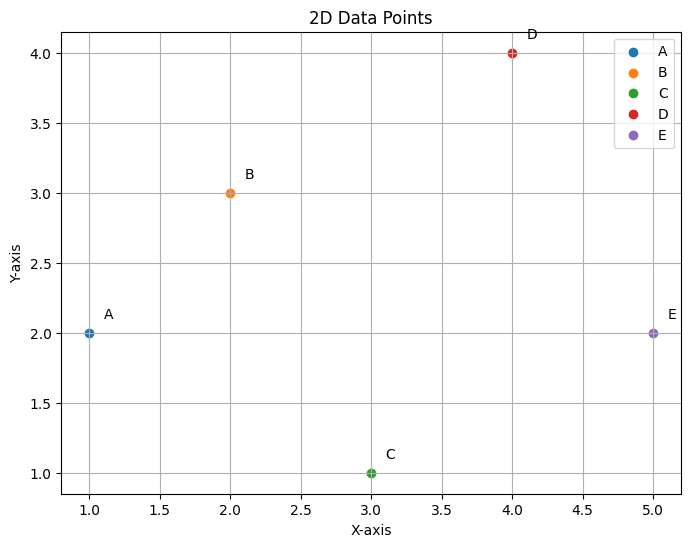

In [3]:
# Sample 2D data points
data = {
    'A': np.array([1, 2]),
    'B': np.array([2, 3]),
    'C': np.array([3, 1]),
    'D': np.array([4, 4]),
    'E': np.array([5, 2])
}

# Plotting the data points
plt.figure(figsize=(8, 6))
for label, point in data.items():
    plt.scatter(point[0], point[1], label=label)
    plt.text(point[0] + 0.1, point[1] + 0.1, label)
plt.title('2D Data Points')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()
plt.show()

### Measuring the Similarities

In [5]:
# Measuing Similarity (Cosine Similarity)
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0
    return dot_product / (norm_vec1 * norm_vec2)

# Example: Calculate cosine similarity between points A and B
similarity_AB = cosine_similarity(data['A'], data['B'])
print(f"Cosine Similarity between A and B: {similarity_AB:.4f}")


Cosine Similarity between A and B: 0.9923


In [7]:
from langchain_huggingface import HuggingFaceEmbeddings

# Initialize the HuggingFaceEmbeddings with a specific model
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
embedding_model

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7805.40it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [10]:
# Create the embedding
text = "Hello, how are you?"
embedding_vector = embedding_model.embed_query(text)
print(f"Length of embedding vector: {len(embedding_vector)}")
print(f"Embedding vector for '{text}':\n{embedding_vector}")

Length of embedding vector: 384
Embedding vector for 'Hello, how are you?':
[0.019096739590168, 0.03446517139673233, 0.09162802249193192, 0.07016535848379135, -0.029946627095341682, -0.08419133722782135, 0.04581354185938835, 0.0049585518427193165, -0.09189332276582718, 0.017400627955794334, -0.008816134184598923, -0.000661465513985604, -0.02855696529150009, -0.021949687972664833, 0.05516670644283295, -0.04983650892972946, 0.08988092094659805, -0.0889570564031601, -0.11235623061656952, 0.03900047764182091, -0.0660708025097847, 0.026095153763890266, 0.036530736833810806, 0.061390358954668045, -0.05712490901350975, -0.05463939905166626, 0.030365537852048874, 0.03238752856850624, 0.012644663453102112, -0.1056857481598854, -0.05834552273154259, 0.06732939183712006, -0.04075591638684273, 0.006439795717597008, 0.005698756780475378, 0.052853189408779144, -0.03977532684803009, -0.11855243891477585, 0.0021161739714443684, -0.016692832112312317, 0.028338104486465454, -0.037437938153743744, -0.021

In [11]:
sentences = [
    "The cat is on the roof.",
    "A dog is in the garden.",
    "The sun is shining brightly.",
    "I love programming in Python.",
    "The weather is nice today."
]

# Generate embeddings for the sentences
embeddings = embedding_model.embed_documents(sentences)
for i, sentence in enumerate(sentences):
    print(f"Sentence: '{sentence}'")
    print(f"Embedding vector (first 5 values): {embeddings[i][:5]}\n")


Sentence: 'The cat is on the roof.'
Embedding vector (first 5 values): [0.09014207869768143, 0.07564272731542587, 0.020247457548975945, 0.012722834944725037, -0.0480131097137928]

Sentence: 'A dog is in the garden.'
Embedding vector (first 5 values): [-0.02028491348028183, -0.03636932373046875, 0.01336704846471548, 0.0028101978823542595, 0.04968708008527756]

Sentence: 'The sun is shining brightly.'
Embedding vector (first 5 values): [0.028243592008948326, 0.11068490892648697, 0.08386965095996857, 0.09629601240158081, 0.023702256381511688]

Sentence: 'I love programming in Python.'
Embedding vector (first 5 values): [-0.05761699751019478, 0.004262271802872419, -0.028153154999017715, 0.025197584182024002, -0.016505617648363113]

Sentence: 'The weather is nice today.'
Embedding vector (first 5 values): [-0.029450982809066772, 0.10326588153839111, 0.15032200515270233, 0.07372087985277176, 0.0008005427080206573]



In [12]:
# Cosine Similarity between all the sentences
similarity_matrix = np.zeros((len(sentences), len(sentences)))
for i in range(len(sentences)):
    for j in range(len(sentences)):
        similarity_matrix[i][j] = cosine_similarity(embeddings[i], embeddings[j]) 
print("Cosine Similarity Matrix:")
print(similarity_matrix)

Cosine Similarity Matrix:
[[1.         0.15868499 0.1011386  0.01452833 0.09119989]
 [0.15868499 1.         0.15789538 0.04355713 0.1386779 ]
 [0.1011386  0.15789538 1.         0.01778759 0.50603794]
 [0.01452833 0.04355713 0.01778759 1.         0.06274021]
 [0.09119989 0.1386779  0.50603794 0.06274021 1.        ]]
